# Route-3 Held-out Recovery, Coverage, SBC, and Synthetic PPC

This notebook evaluates the exploratory three-member ensemble on 128
independent synthetic cortical-rate observations. The GO criteria artifact was
frozen before these theta values were generated. No threshold is changed after
viewing results.

Scope: recoverability of eight model parameters in synthetic cortical-rate
observable space only. This does not validate an EEG measurement model or
unlock real-EEG inference.

In [1]:
from __future__ import annotations
import json
import os
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / "S4_sbi" / "src").exists():
    for parent in PROJECT_ROOT.parents:
        if (parent / "S4_sbi" / "src").exists():
            PROJECT_ROOT = parent
            break
for path in (PROJECT_ROOT / "S4_sbi" / "src", PROJECT_ROOT):
    if str(path) not in sys.path:
        sys.path.insert(0, str(path))

from sleep_sbi.route3_global_robustness import RESULTS_ROOT, rate_feature_names
from sleep_sbi.route3_heldout_validation import (
    HELDOUT_ROOT,
    POSTERIOR_SAMPLES_PER_CASE,
    analyze_recovery_and_coverage,
    evaluate_go_decision,
    generate_heldout_posterior_samples,
    run_heldout_dataset,
    run_synthetic_ppc,
)
from sleep_sbi.route3_synthetic_preflight import PARAMETER_NAMES

BANK_ROOT = RESULTS_ROOT / "simulation_bank_2048"
FIGURE_DIR = HELDOUT_ROOT / "figures"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)
assert Path(sys.prefix).name.lower() == "neurolib"
print("Environment:", os.environ.get("CONDA_DEFAULT_ENV"))
print("Python:", sys.executable)

Environment: neurolib
Python: C:\Users\YUS190\AppData\Local\anaconda3\envs\neurolib\python.exe


## 1. Immutable GO criteria

Formal GO requires simulation reliability, almost entirely finite/in-support
posterior samples, nominally compatible 80% and 90% coverage for at least 7/8
parameters, no severe undercoverage, recovery improvement for at least 6/8,
honest contraction for at least 6/8, PPC improvement, and stable ensemble
conclusions. Conditional GO has weaker but still pre-specified limits.

In [2]:
criteria_path = HELDOUT_ROOT / "go_criteria_frozen.json"
criteria = json.loads(criteria_path.read_text(encoding="utf-8"))
display(pd.DataFrame(criteria["formal_go"].items(), columns=["criterion", "frozen value"]))
print("Frozen UTC:", criteria["frozen_utc"])

,criterion,frozen value
0,training_failure_rate_max,0.01
1,heldout_failure_rate_max,0.01
2,posterior_finite_and_in_prior_rate_min,0.999
3,coverage_80_or_90_wilson_contains_nominal_para...,7
4,severe_undercoverage_definition,observed coverage < nominal-0.15 and Wilson up...
5,severe_undercoverage_parameters_max,0
6,median_error_better_than_prior_parameters_min,6
7,overall_median_error_improvement_min_fraction,0.1
8,meaningful_contraction_definition,median 90% CI width < 0.90 prior width
9,meaningful_contraction_with_reasonable_coverag...,6


Frozen UTC: 2026-07-27T20:58:09.411016+00:00


## 2. Independent 128-case held-out dataset

The scrambled Sobol sequence and simulator seed schedule differ from training.
Exact theta duplicates are rejected. Held-out observations never refit scaling,
features, architecture, or hyperparameters.

In [3]:
bank_path = BANK_ROOT / "route3_cortex_rate_14d_bank_2048.npz"
split_path = BANK_ROOT / "split_and_scaling.npz"
heldout = run_heldout_dataset(bank_path, max_workers=6)
display(pd.DataFrame([heldout["manifest"]]))
assert heldout["manifest"]["success"] == 128
assert heldout["manifest"]["exact_training_theta_duplicates"] == 0

,attempted,success,failed,failure_rate,sobol_seed,simulator_seed_base,exact_training_theta_duplicates,contract_hash
0,128,128,0,0.0,20260802,910001,0,78d0da704422a03917ef4c68207f5e8e8213b0c6f6279d...


## 3. Equal-ensemble posterior samples

Each case has exactly 4,096 prior-supported samples, split as evenly as possible
among three independently initialized members. Samples and member labels are
checkpointed per case. Posterior width is not itself a success metric.

In [4]:
posterior = generate_heldout_posterior_samples(
    heldout["path"], bank_path, split_path
)
assert posterior["samples"].shape == (128, POSTERIOR_SAMPLES_PER_CASE, 8)
assert np.isfinite(posterior["samples"]).all()
assert ((posterior["samples"] >= 0) & (posterior["samples"] <= 1)).all()
print("Posterior samples:", posterior["samples"].shape)
print("Sampling runtime sum (s):", posterior["runtime_s"].sum())

Posterior samples: (128, 4096, 8)
Sampling runtime sum (s): 22.279004400828853


## 4. Parameter recovery against prior-median baseline

Axes use normalized prior coordinates. The dashed diagonal is perfect recovery.
Posterior medians are compared with the fixed prior median (0.5). Error bars
show 90% credible intervals.

,parameter,posterior_median_mae,posterior_median_rmse,posterior_mean_mae,prior_median_mae,mae_improvement_fraction,rank_correlation,median_90_ci_width,median_80_ci_width,median_50_ci_width
0,mue,0.154542,0.189808,0.154675,0.250000,0.381833,0.753960,0.515698,0.425960,0.234925
1,mui,0.004985,0.010953,0.005147,0.250000,0.980059,0.999273,0.021145,0.016681,0.008976
2,b,0.095167,0.131531,0.098755,0.250000,0.619333,0.894405,0.388571,0.303420,0.160734
3,tauA,0.191231,0.236389,0.190879,0.250000,0.235076,0.549813,0.651477,0.532051,0.297586
4,g_LK,0.157871,0.207844,0.160637,0.250000,0.368518,0.681663,0.503995,0.400801,0.218416
5,g_h,0.133758,0.179195,0.134211,0.250000,0.464967,0.792895,0.456547,0.352041,0.187219
6,c_th2ctx,0.150546,0.194839,0.151663,0.250000,0.397818,0.740976,0.501203,0.401295,0.215999
7,c_ctx2th,0.251483,0.290151,0.251081,0.250031,-0.005809,-0.038500,0.779980,0.637932,0.350513


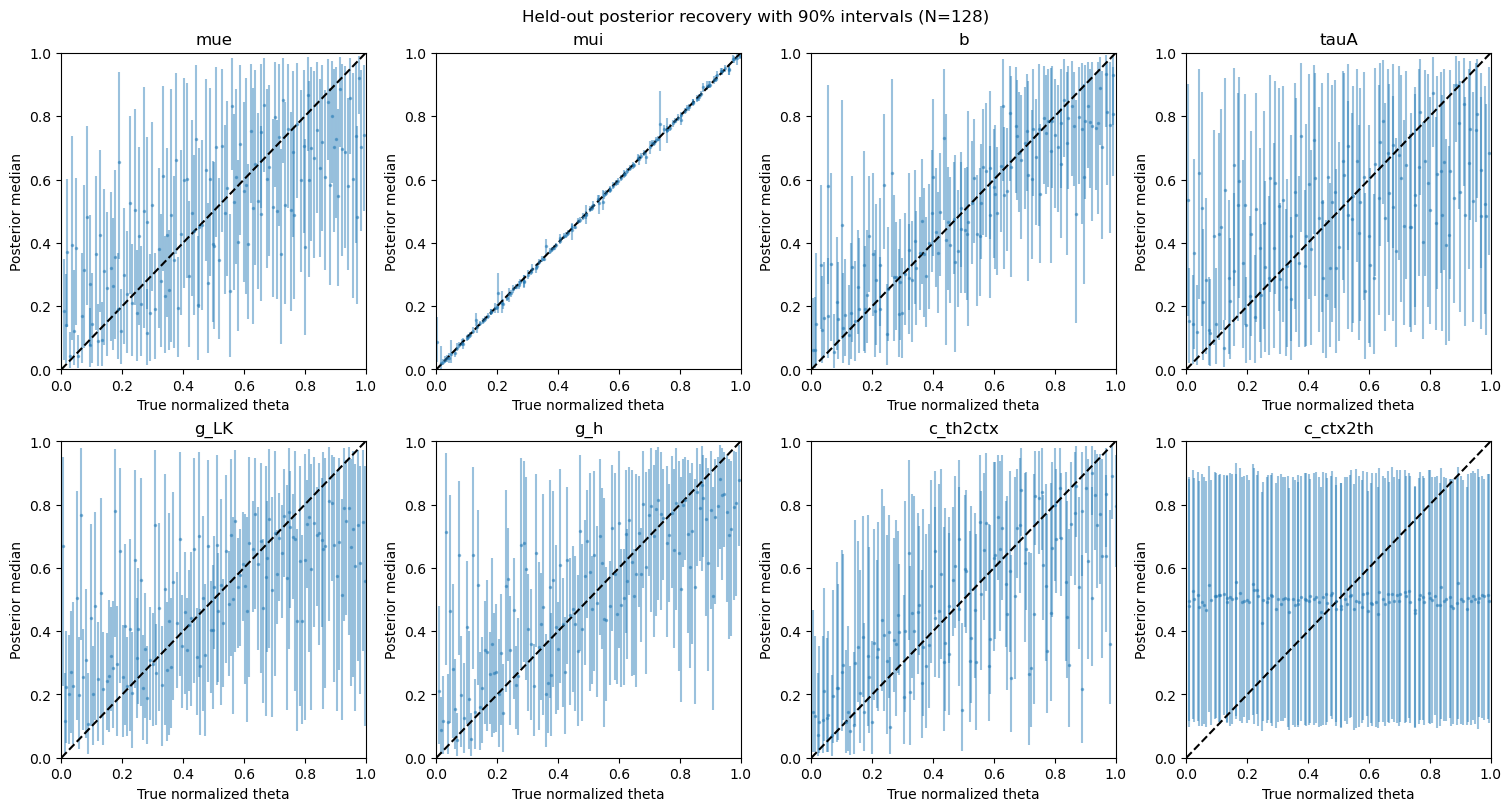

In [5]:
recovery = analyze_recovery_and_coverage(posterior["path"])
recovery_table = recovery["recovery"]
display(recovery_table)

fig, axes = plt.subplots(2, 4, figsize=(15, 8), constrained_layout=True)
for parameter_index, ax in enumerate(axes.flat):
    true = recovery["theta"][:, parameter_index]
    samples = recovery["samples"][:, :, parameter_index]
    median = np.median(samples, axis=1)
    low, high = np.quantile(samples, [0.05, 0.95], axis=1)
    ax.errorbar(true, median, yerr=[median-low, high-median], fmt=".", ms=3, alpha=.45)
    ax.plot([0,1], [0,1], color="black", ls="--")
    ax.set(xlabel="True normalized theta", ylabel="Posterior median", title=PARAMETER_NAMES[parameter_index], xlim=(0,1), ylim=(0,1))
fig.suptitle("Held-out posterior recovery with 90% intervals (N=128)")
fig.savefig(FIGURE_DIR / "heldout_recovery_scatter.png", dpi=180)
fig.savefig(FIGURE_DIR / "heldout_recovery_scatter.svg")
plt.show()

## 5. Coverage and binomial uncertainty

Points are empirical coverage and vertical bars are Wilson 95% binomial
intervals. A nominal level is compatible only if it lies inside the interval.
The decision uses 80% and 90% levels parameter by parameter.

,estimator,parameter,nominal_level,covered,n,empirical_coverage,wilson_95_low,wilson_95_high,nominal_inside_wilson,severe_undercoverage
0,ensemble,mue,0.5,49,128,0.382812,0.303186,0.469268,False,False
1,ensemble,mue,0.8,90,128,0.703125,0.618995,0.775418,False,False
2,ensemble,mue,0.9,105,128,0.820312,0.744784,0.877175,False,False
3,ensemble,mui,0.5,95,128,0.742188,0.660131,0.810131,False,False
4,ensemble,mui,0.8,117,128,0.914062,0.852659,0.951337,False,False
5,ensemble,mui,0.9,123,128,0.960938,0.911813,0.983201,False,False
6,ensemble,b,0.5,68,128,0.531250,0.445154,0.615525,True,False
7,ensemble,b,0.8,100,128,0.781250,0.702016,0.844095,True,False
8,ensemble,b,0.9,115,128,0.898438,0.833975,0.939681,True,False
9,ensemble,tauA,0.5,50,128,0.390625,0.310470,0.477154,False,False


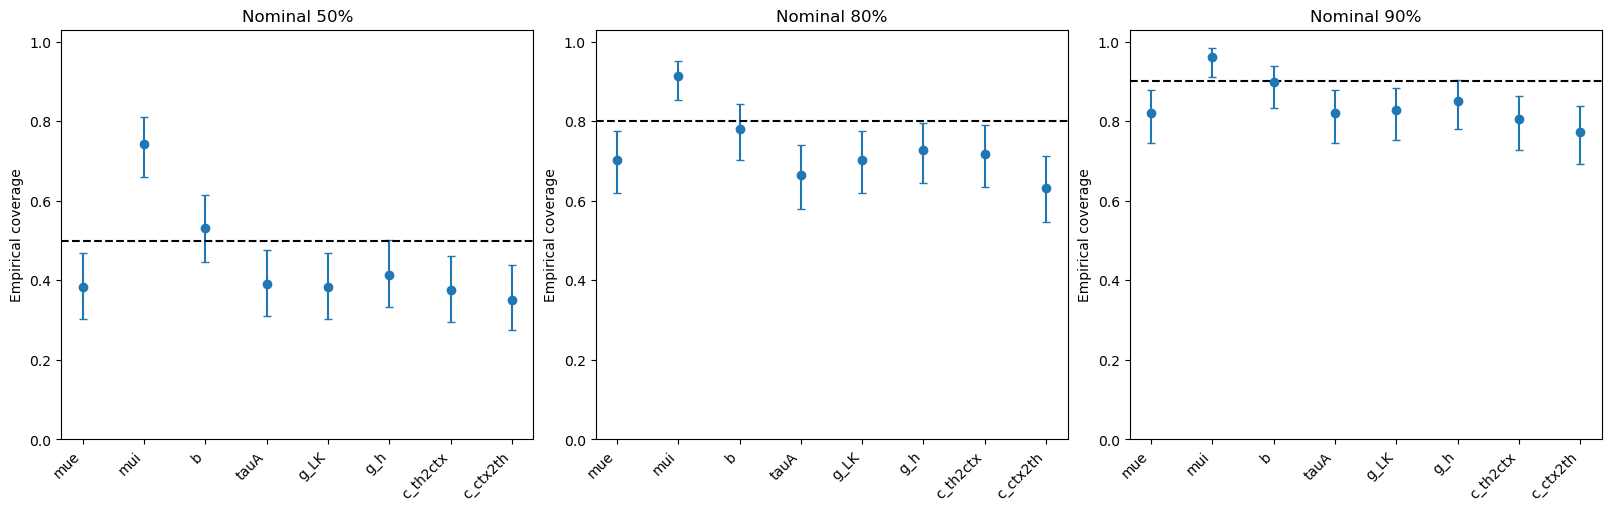

In [6]:
coverage = recovery["coverage"]
ensemble_coverage = coverage[coverage.estimator == "ensemble"]
display(ensemble_coverage)

fig, axes = plt.subplots(1, 3, figsize=(16, 5), constrained_layout=True)
for ax, level in zip(axes, (0.5, 0.8, 0.9)):
    subset = ensemble_coverage[ensemble_coverage.nominal_level == level].set_index("parameter").loc[list(PARAMETER_NAMES)]
    values = subset.empirical_coverage.to_numpy()
    lower = values - subset.wilson_95_low.to_numpy()
    upper = subset.wilson_95_high.to_numpy() - values
    ax.errorbar(range(8), values, yerr=[lower, upper], fmt="o", capsize=3)
    ax.axhline(level, color="black", ls="--")
    ax.set_xticks(range(8), PARAMETER_NAMES, rotation=45, ha="right")
    ax.set(ylabel="Empirical coverage", title=f"Nominal {int(level*100)}%", ylim=(0,1.03))
fig.savefig(FIGURE_DIR / "heldout_coverage.png", dpi=180)
fig.savefig(FIGURE_DIR / "heldout_coverage.svg")
plt.show()

## 6. SBC rank diagnostics

Ranks are normalized because ensemble and member sample counts differ slightly.
Ten-bin chi-square values are descriptive warnings, not standalone decisions.
Coverage, bias, contraction, and the 128-case sample size remain primary.

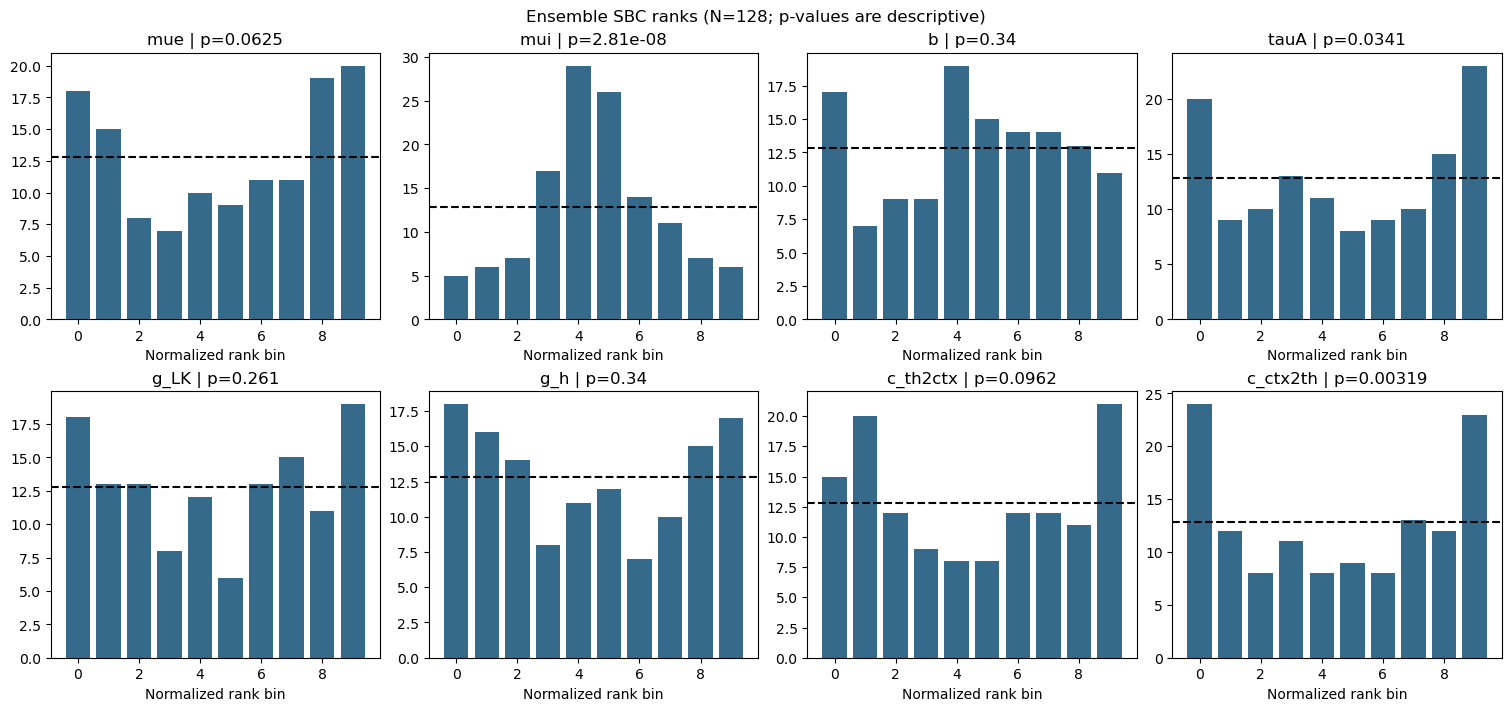

,rank_mean,rank_std,chi_square_p_value
parameter,,,
mue,0.528802,0.327108,6.245167e-02
mui,0.510370,0.209568,2.805669e-08
b,0.511043,0.283326,3.404609e-01
tauA,0.521361,0.326372,3.410132e-02
g_LK,0.506623,0.319601,2.610123e-01
g_h,0.486978,0.314130,3.404609e-01
c_th2ctx,0.497847,0.326003,9.621672e-02
c_ctx2th,0.501375,0.340210,3.185744e-03


In [7]:
sbc = recovery["sbc"]
ensemble_sbc = sbc[sbc.estimator == "ensemble"].set_index("parameter").loc[list(PARAMETER_NAMES)]
fig, axes = plt.subplots(2, 4, figsize=(15, 7), constrained_layout=True)
for parameter, ax in zip(PARAMETER_NAMES, axes.flat):
    row = ensemble_sbc.loc[parameter]
    counts = [row[f"bin_{i}"] for i in range(10)]
    ax.bar(np.arange(10), counts, color="#356a8a")
    ax.axhline(128/10, color="black", ls="--")
    ax.set(title=f"{parameter} | p={row.chi_square_p_value:.3g}", xlabel="Normalized rank bin")
fig.suptitle("Ensemble SBC ranks (N=128; p-values are descriptive)")
fig.savefig(FIGURE_DIR / "heldout_sbc_ranks.png", dpi=180)
fig.savefig(FIGURE_DIR / "heldout_sbc_ranks.svg")
plt.show()
display(ensemble_sbc[["rank_mean", "rank_std", "chi_square_p_value"]])

## 7. Ensemble disagreement and posterior ridges

Member-median ranges are measured in prior widths. Ridge correlations summarize
posterior dependence for `g_LK/g_h` and the two coupling parameters. Honest
ridge uncertainty is acceptable; false narrowness or undercoverage is not.

,parameter,mean_member_median_range,median_member_median_range,max_member_median_range
0,mue,0.047241,0.038543,0.209958
1,mui,0.009291,0.005971,0.140650
2,b,0.066698,0.054870,0.223541
3,tauA,0.057466,0.048428,0.204478
4,g_LK,0.072469,0.069041,0.176946
5,g_h,0.058247,0.051550,0.233747
6,c_th2ctx,0.069136,0.061801,0.211514
7,c_ctx2th,0.030766,0.029095,0.100727


,case,g_LK_g_h_spearman,c_th2ctx_c_ctx2th_spearman
count,128.000000,128.000000,128.000000
mean,63.500000,0.166587,-0.000390
std,37.094474,0.192395,0.019457
min,0.000000,-0.177191,-0.054361
25%,31.750000,-0.004832,-0.015902
50%,63.500000,0.154477,-0.000145
75%,95.250000,0.312712,0.010730
max,127.000000,0.618461,0.065276


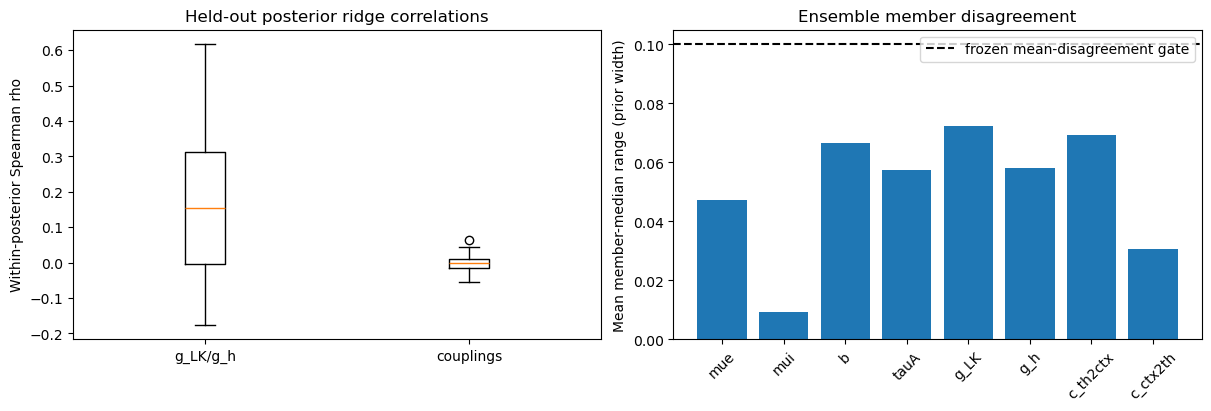

In [8]:
disagreement = recovery["disagreement"]
ridges = recovery["ridges"]
display(disagreement)
display(ridges.describe())
fig, axes = plt.subplots(1, 2, figsize=(12, 4), constrained_layout=True)
axes[0].boxplot([ridges.g_LK_g_h_spearman, ridges.c_th2ctx_c_ctx2th_spearman], tick_labels=["g_LK/g_h", "couplings"])
axes[0].set(ylabel="Within-posterior Spearman rho", title="Held-out posterior ridge correlations")
axes[1].bar(disagreement.parameter, disagreement.mean_member_median_range)
axes[1].axhline(.1, color="black", ls="--", label="frozen mean-disagreement gate")
axes[1].tick_params(axis="x", rotation=45)
axes[1].set(ylabel="Mean member-median range (prior width)", title="Ensemble member disagreement")
axes[1].legend()
fig.savefig(FIGURE_DIR / "heldout_ridges_disagreement.png", dpi=180)
fig.savefig(FIGURE_DIR / "heldout_ridges_disagreement.svg")
plt.show()

## 8. New-seed synthetic posterior predictive checks

Thirty-two cases are selected by a fixed random seed before looking at PPC.
Each receives 16 posterior theta draws and 16 independent prior-predictive
draws. Both are newly simulated with seeds unused by held-out observations.
Typical cases are closest to the median recovery score within the random set;
worst cases are the five largest recovery errors within that same set.

,cases,posterior_draws_per_case,posterior_predictive_attempted,posterior_predictive_failed,prior_predictive_attempted,prior_predictive_failed,features_posterior_better,overall_posterior_scaled_error,overall_prior_scaled_error,overall_improvement_fraction
0,32,16,512,0,512,0,14,0.09638,0.643293,0.850178


,feature,posterior_predictive_median_scaled_abs_error,prior_predictive_median_scaled_abs_error,improvement_fraction,posterior_better
0,r_exc_mean_hz,0.041291,0.628501,0.934303,True
1,r_exc_std_hz,0.053793,0.718426,0.925124,True
2,r_exc_relative_so_power,0.098164,0.682875,0.856249,True
3,r_exc_relative_sigma_power,0.262894,0.751698,0.650267,True
4,r_exc_so_peak_frequency_hz,0.000000,0.500000,1.000000,True
5,r_exc_sigma_peak_frequency_hz,0.333333,0.500000,0.333333,True
6,r_exc_spectral_entropy_0p5_20,0.119848,0.692722,0.826989,True
7,r_inh_mean_hz,0.041034,0.693815,0.940857,True
8,r_inh_std_hz,0.063455,0.654015,0.902976,True
9,r_inh_relative_so_power,0.094595,0.632571,0.850459,True


,random_case_ids,worst_recovery_cases_within_random_set,typical_cases_closest_to_random_set_median_recovery,case_selection_seed,draws_per_case
0,"[3, 4, 9, 11, 21, 23, 24, 29, 38, 39, 40, 46, ...","[99, 54, 63, 11, 29]","[70, 114, 50, 72, 65]",20260804,16


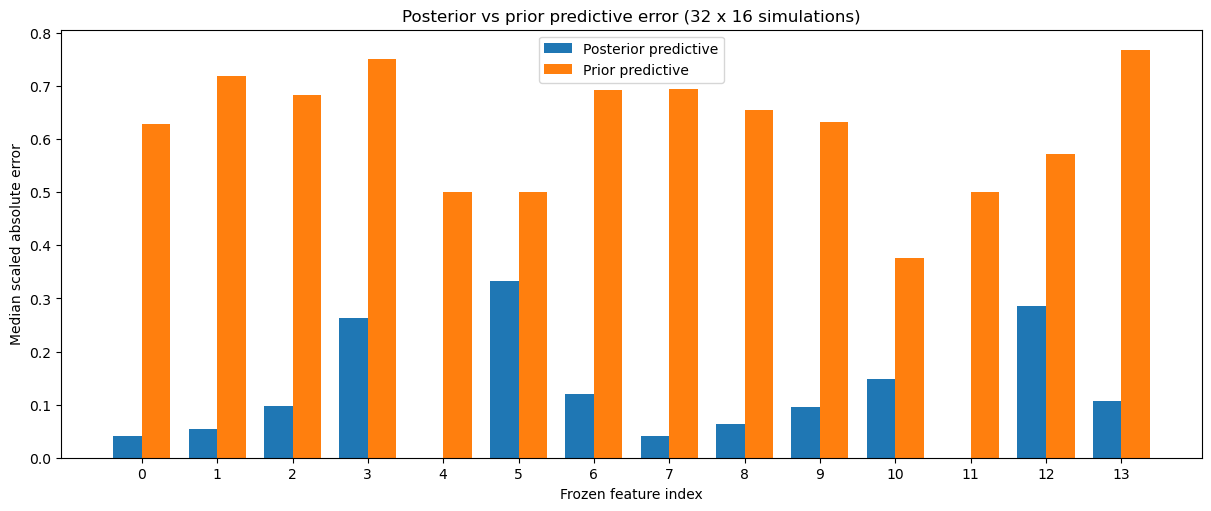

In [9]:
ppc = run_synthetic_ppc(
    recovery, heldout["path"], bank_path, split_path, max_workers=6
)
display(pd.DataFrame([ppc["summary"]]))
display(ppc["metrics"])
display(pd.DataFrame([ppc["selection"]]))

metrics = ppc["metrics"]
fig, ax = plt.subplots(figsize=(12, 5), constrained_layout=True)
positions = np.arange(14)
width = .38
ax.bar(positions-width/2, metrics.posterior_predictive_median_scaled_abs_error, width, label="Posterior predictive")
ax.bar(positions+width/2, metrics.prior_predictive_median_scaled_abs_error, width, label="Prior predictive")
ax.set_xticks(positions, range(14))
ax.set(xlabel="Frozen feature index", ylabel="Median scaled absolute error", title="Posterior vs prior predictive error (32 x 16 simulations)")
ax.legend()
fig.savefig(FIGURE_DIR / "synthetic_ppc_comparison.png", dpi=180)
fig.savefig(FIGURE_DIR / "synthetic_ppc_comparison.svg")
plt.show()

## 9. Frozen decision

The following result is computed directly from the immutable criteria. Training
success and a strong PPC do not override systematic calibration failure.

In [10]:
decision = evaluate_go_decision(
    criteria_path,
    BANK_ROOT / "bank_manifest.json",
    HELDOUT_ROOT / "dataset" / "heldout_manifest.json",
    recovery,
    ppc,
)
display(pd.DataFrame([{"check": key, "value": value} for key, value in decision["checks"].items()]))
print("FORMAL DECISION:", decision["decision"])
assert decision["decision"] in {"GO", "CONDITIONAL GO", "NO-GO"}

,check,value
0,training_failure_gate,True
1,heldout_failure_gate,True
2,posterior_finite_support_gate,True
3,coverage_compatible_parameter_count,1
4,coverage_compatible_gate,False
5,severe_undercoverage_parameter_count,1
6,severe_undercoverage_gate,False
7,better_than_prior_parameter_count,7
8,better_than_prior_gate,True
9,overall_recovery_improvement_fraction,0.430218


FORMAL DECISION: NO-GO


## Conclusion

The exploratory ensemble improves median recovery over the prior baseline for
seven parameters and strongly improves 14D synthetic PPC. Nevertheless,
nominal coverage is compatible for too few parameters, and `c_ctx2th` shows no
recovery improvement plus severe 80% undercoverage. Under the frozen rules the
decision is **NO-GO** for claiming validated eight-parameter Route-3 recovery.

Recommended next work is not an automatic 4K/8K expansion. First address the
weak `c_ctx2th` direction and calibration: consider a pre-registered seven-
parameter experiment with `c_ctx2th` fixed, reparameterization, feature
quantization changes decided independently of this held-out set, or
calibration-aware training. Real-EEG SNPE remains prohibited by the unresolved
measurement model.